# Task 1: Problem Identification

## Selected Problem Type: Image Classification

The given dataset represents an **Image Classification** problem.

In image classification, the goal is to assign a single label or category to an input image.

The dataset contains manufacturing product images belonging to one of four classes:
- normal
- scratch
- dent
- stain

Each image belongs to only one class, making this a multi-class image classification problem.

The dataset does not contain:
- bounding box annotations (required for object detection)
- pixel-level masks (required for semantic or instance segmentation)

Therefore, image classification is the most appropriate computer vision task for this dataset.

# Task 2: Dataset Exploration

In [23]:
import os
import matplotlib.pyplot as plt
from PIL import Image

In [24]:
dataset_path = "images"

classes = os.listdir(dataset_path)

print("Classes:", classes)

Classes: ['.DS_Store', 'dent', 'normal', 'scratch', 'stain']


## Number of Classes

The dataset contains four image classes:
- normal
- scratch
- dent
- stain

This makes it a multi-class image classification problem.

In [25]:
image_count = {}

for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    
    if os.path.isdir(class_path):
        image_count[cls] = len(os.listdir(class_path))

print(image_count)

{'dent': 120, 'normal': 120, 'scratch': 120, 'stain': 120}


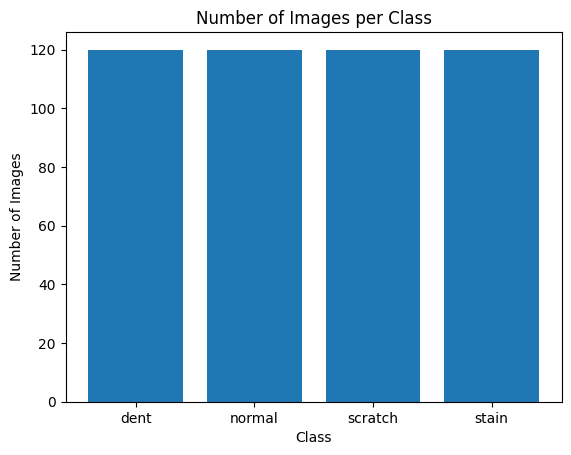

In [26]:
plt.bar(image_count.keys(), image_count.values())

plt.title("Number of Images per Class")

plt.xlabel("Class")

plt.ylabel("Number of Images")

plt.show()

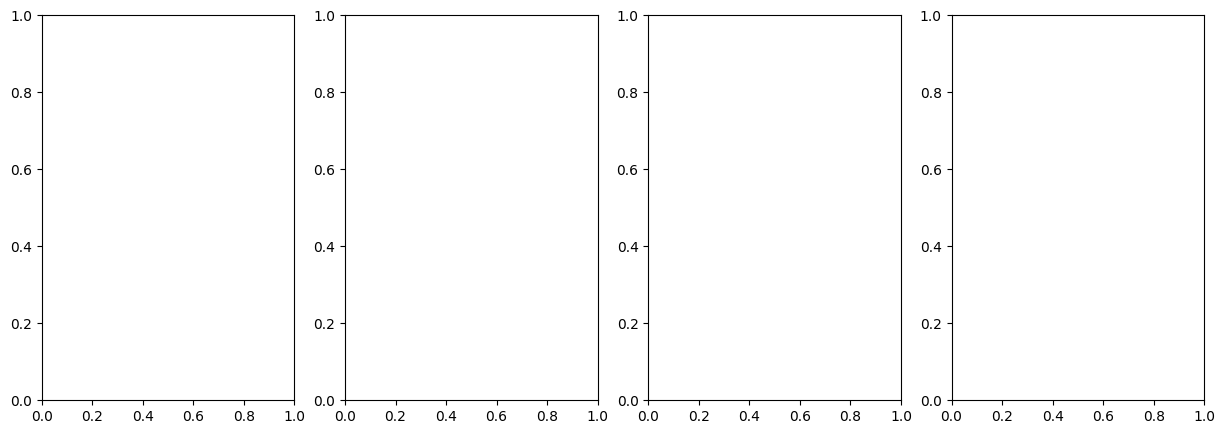

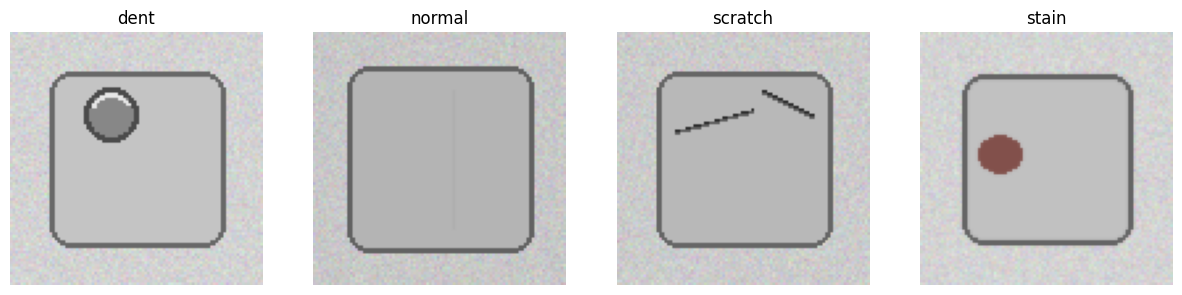

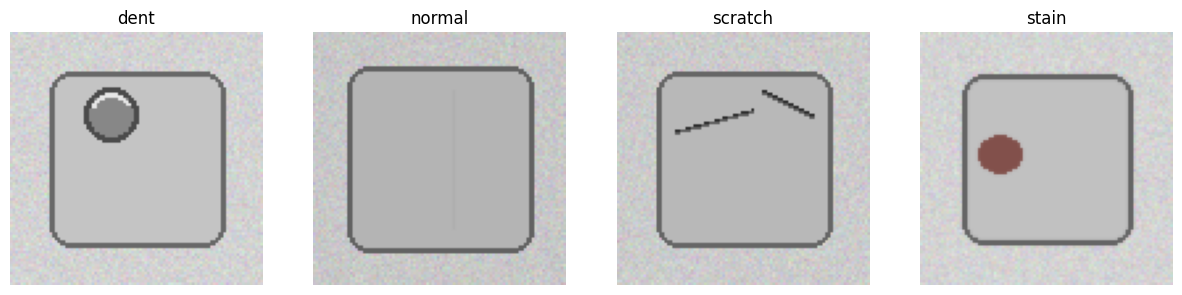

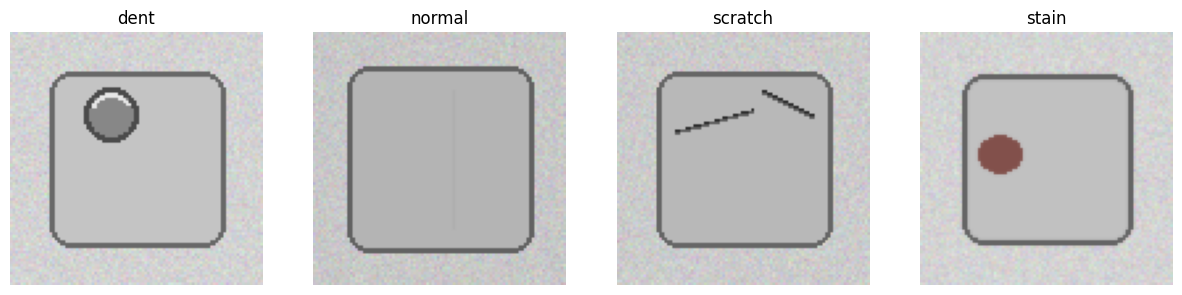

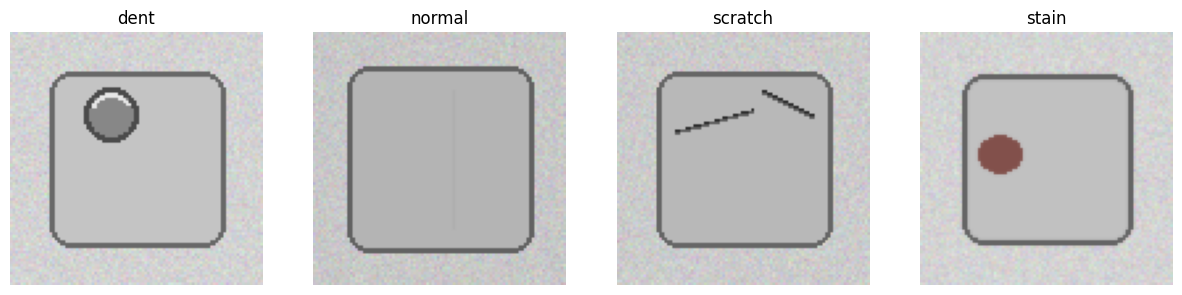

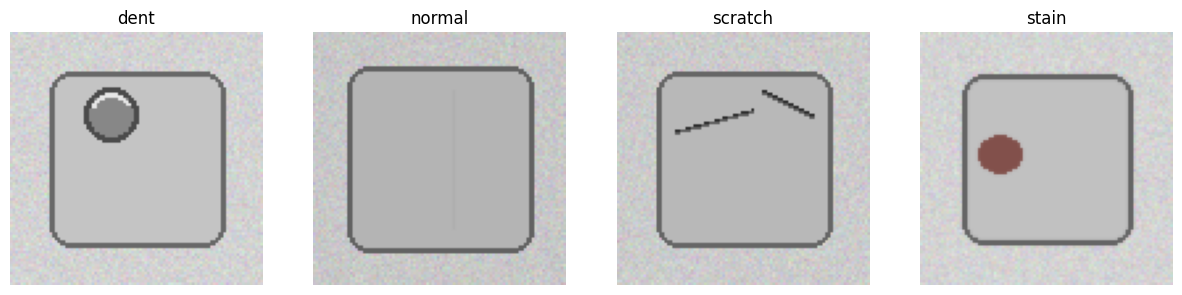

In [27]:
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

for i, cls in enumerate(classes):

    class_path = os.path.join(dataset_path, cls)

    valid_classes = [cls for cls in classes if os.path.isdir(os.path.join(dataset_path, cls))]

    fig, axes = plt.subplots(1, 4, figsize=(15, 5))

    for i, cls in enumerate(valid_classes):
        class_path = os.path.join(dataset_path, cls)
        image_name = os.listdir(class_path)[0]

        image_path = os.path.join(class_path, image_name)
        img = Image.open(image_path)
        axes[i].imshow(img)
        axes[i].set_title(cls)
        axes[i].axis('off')

    plt.show()

    image_path = os.path.join(class_path, image_name)

    img = Image.open(image_path)

    axes[i].imshow(img)

    axes[i].set_title(cls)

    axes[i].axis('off')

plt.show()

In [28]:
for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    for cls in classes:
        class_path = os.path.join(dataset_path, cls)
        if not os.path.isdir(class_path):
            continue

        image_name = os.listdir(class_path)[0]
        image_path = os.path.join(class_path, image_name)

        img = Image.open(image_path)

        print(cls, ":", img.size)

    image_path = os.path.join(class_path, image_name)

    img = Image.open(image_path)

    print(cls, ":", img.size)

dent : (96, 96)
normal : (96, 96)
scratch : (96, 96)
stain : (96, 96)
stain : (96, 96)
dent : (96, 96)
normal : (96, 96)
scratch : (96, 96)
stain : (96, 96)
stain : (96, 96)
dent : (96, 96)
normal : (96, 96)
scratch : (96, 96)
stain : (96, 96)
stain : (96, 96)
dent : (96, 96)
normal : (96, 96)
scratch : (96, 96)
stain : (96, 96)
stain : (96, 96)
dent : (96, 96)
normal : (96, 96)
scratch : (96, 96)
stain : (96, 96)
stain : (96, 96)


In [29]:
import tensorflow as tf

print("TensorFlow Loaded")

TensorFlow Loaded


# Task 3: Image Preprocessing

Image preprocessing was performed to prepare the dataset for CNN training.

The preprocessing pipeline included:
- Image resizing
- Pixel normalization
- Dataset splitting
- Data augmentation

In [30]:
import numpy as np
import os

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split

In [31]:
IMG_SIZE = 96

In [32]:
X = []
y = []

classes = ['dent', 'normal', 'scratch', 'stain']

for label, cls in enumerate(classes):

    class_path = os.path.join("images", cls)

    for image_name in os.listdir(class_path):

        image_path = os.path.join(class_path, image_name)

        img = load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))

        img_array = img_to_array(img)

        X.append(img_array)

        y.append(label)

X = np.array(X)

y = np.array(y)

print("Image Data Shape:", X.shape)

print("Label Shape:", y.shape)

Image Data Shape: (480, 96, 96, 3)
Label Shape: (480,)


## Image Resizing

All images were resized to 96 × 96 pixels to ensure consistent input dimensions for CNN training.

In [33]:
X = X / 255.0

print("Minimum Pixel Value:", X.min())

print("Maximum Pixel Value:", X.max())

Minimum Pixel Value: 0.1764706
Maximum Pixel Value: 1.0


## Pixel Normalization

Pixel values were normalized from the range 0–255 to 0–1.

Normalization improves CNN training stability and convergence speed.

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)

print("Testing Data Shape:", X_test.shape)

Training Data Shape: (384, 96, 96, 3)
Testing Data Shape: (96, 96, 96, 3)


## Train-Test Split

The dataset was divided into:
- 80% training data
- 20% testing data

Stratified splitting was used to preserve equal class distribution across training and testing datasets.

In [35]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

## Data Augmentation

Data augmentation was applied to increase dataset diversity and improve CNN generalization.

Techniques used:
- Rotation
- Zooming
- Horizontal flipping

## Preprocessing Result

The dataset was successfully converted into CNN-ready format.

Final dataset structure:
- Training images: 384
- Testing images: 96
- Image dimensions: 96 × 96 × 3

Pixel normalization scaled image values into the range 0–1 for efficient CNN training.

# Task 4: CNN Model Creation

In [36]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [37]:
model = Sequential()

# --------------------------------
# First Convolution Block
# --------------------------------
model.add(
    Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(96, 96, 3)
    )
)

model.add(MaxPooling2D(pool_size=(2, 2)))

# --------------------------------
# Second Convolution Block
# --------------------------------
model.add(
    Conv2D(
        64,
        (3, 3),
        activation='relu'
    )
)

model.add(MaxPooling2D(pool_size=(2, 2)))

# --------------------------------
# Flatten Layer
# --------------------------------
model.add(Flatten())

# --------------------------------
# Dense Layer
# --------------------------------
model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

# --------------------------------
# Output Layer
# --------------------------------
model.add(Dense(4, activation='softmax'))

model.summary()

C:\Users\Aayushi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,984,964 (15.20 MB)

 Trainable params: 3,984,964 (15.20 MB)

 Non-trainable params: 0 (0.00 B)

## CNN Architecture

The CNN architecture consists of:
- Convolutional layers for feature extraction
- ReLU activation functions
- MaxPooling layers for dimensionality reduction
- Flatten layer for converting feature maps into vectors
- Dense layer for classification learning
- Softmax output layer for multi-class prediction

### Convolution Layer

Convolution layers extract important visual patterns such as edges, textures, scratches, dents, and stains from images.

### Activation Function

The ReLU activation function was used to introduce non-linearity into the CNN model.

ReLU helps the CNN learn complex image patterns efficiently.

### Pooling Layer

MaxPooling layers reduce feature map dimensions while preserving important image information.

Pooling improves computational efficiency and helps reduce overfitting.

### Flatten Layer

The Flatten layer converts multidimensional feature maps into a one-dimensional vector before classification.

### Dense Layer

Dense layers perform high-level learning and classification based on extracted image features.

### Output Layer

The output layer contains 4 neurons corresponding to:
- dent
- normal
- scratch
- stain

Softmax activation was used for multi-class classification.

In [38]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Model Compilation

The CNN model was compiled using:
- Adam optimizer
- Sparse categorical crossentropy loss
- Accuracy evaluation metric

### Loss Function

Sparse categorical crossentropy was used because the dataset contains multiple image classes represented as integer labels.

# Task 5: Model Training and Evaluation

In [39]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - accuracy: 0.2508 - loss: 1.7081 - val_accuracy: 0.2338 - val_loss: 1.3936
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 0.3192 - loss: 1.3887 - val_accuracy: 0.4545 - val_loss: 1.3377
Epoch 3/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.4235 - loss: 1.3036 - val_accuracy: 0.4545 - val_loss: 1.2395
Epoch 4/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - accuracy: 0.5798 - loss: 1.0708 - val_accuracy: 0.6104 - val_loss: 0.9545
Epoch 5/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.7036 - loss: 0.8250 - val_accuracy: 0.7662 - val_loss: 0.6793
Epoch 6/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - accuracy: 0.7720 - loss: 0.5994 - val_accuracy: 0.7403 - val_loss: 0.5811
Epoch 7/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.7948 - loss: 0.5165 - val_accuracy: 0.7792 - val_loss: 0.4994
Epoch 8/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.8469 - loss: 0.4438 - val_accuracy: 0.7792 

## Training Observation

During CNN training:
- Training accuracy gradually increased
- Loss values decreased over epochs
- Validation accuracy improved steadily

This indicates successful feature learning by the CNN model.

In [40]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)

print("Test Accuracy:", accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9375 - loss: 0.2122
Test Loss: 0.21218286454677582
Test Accuracy: 0.9375


## Testing Performance

The CNN model was evaluated on unseen test images to measure generalization performance.

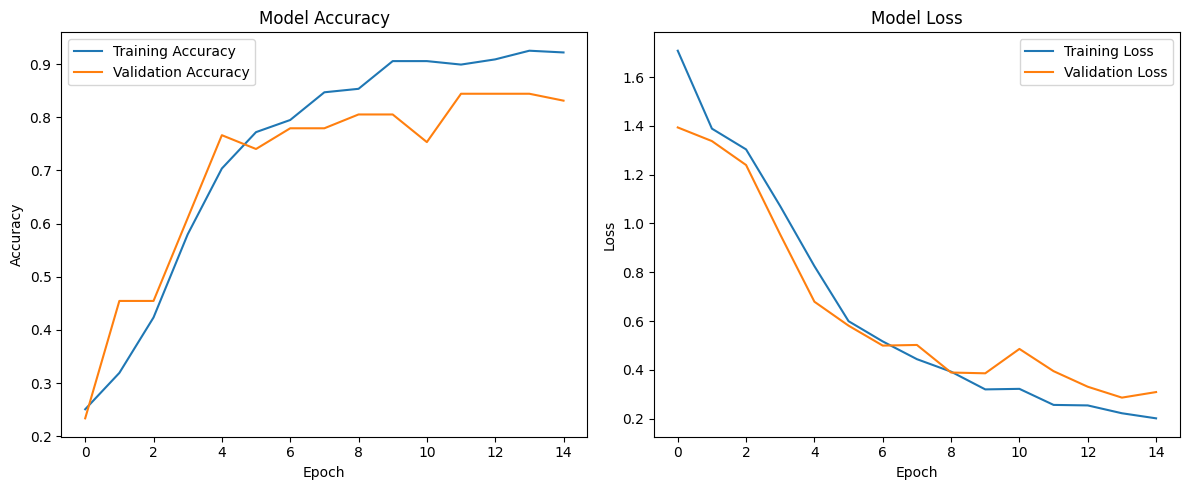

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --------------------------------
# Accuracy Curve
# --------------------------------
axes[0].plot(history.history['accuracy'])

axes[0].plot(history.history['val_accuracy'])

axes[0].set_title("Model Accuracy")

axes[0].set_xlabel("Epoch")

axes[0].set_ylabel("Accuracy")

axes[0].legend([
    'Training Accuracy',
    'Validation Accuracy'
])

# --------------------------------
# Loss Curve
# --------------------------------
axes[1].plot(history.history['loss'])

axes[1].plot(history.history['val_loss'])

axes[1].set_title("Model Loss")

axes[1].set_xlabel("Epoch")

axes[1].set_ylabel("Loss")

axes[1].legend([
    'Training Loss',
    'Validation Loss'
])

plt.tight_layout()

plt.savefig("results/accuracy_loss_curves.png")

plt.show()

In [42]:
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step 


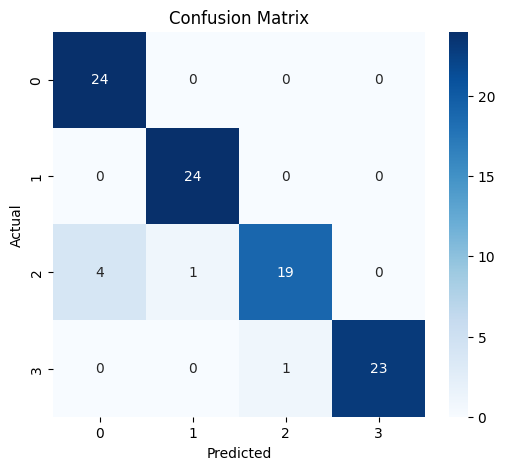

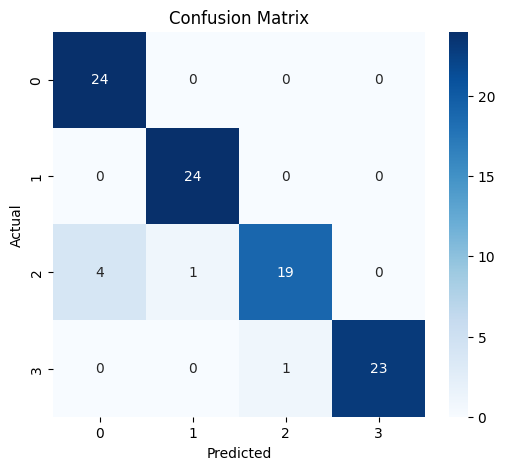

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig("results/confusion_matrix.png")

plt.show()

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig("results/confusion_matrix.png")

plt.show()

In [45]:
from sklearn.metrics import classification_report

In [46]:
print(classification_report(
    y_test,
    y_pred_classes,
    target_names=classes
))

              precision    recall  f1-score   support

        dent       0.86      1.00      0.92        24
      normal       0.96      1.00      0.98        24
     scratch       0.95      0.79      0.86        24
       stain       1.00      0.96      0.98        24

    accuracy                           0.94        96
   macro avg       0.94      0.94      0.94        96
weighted avg       0.94      0.94      0.94        96



## CNN Evaluation Analysis

The CNN model successfully learned visual features from manufacturing images.

The confusion matrix and classification report were used to evaluate classification performance across all defect categories.

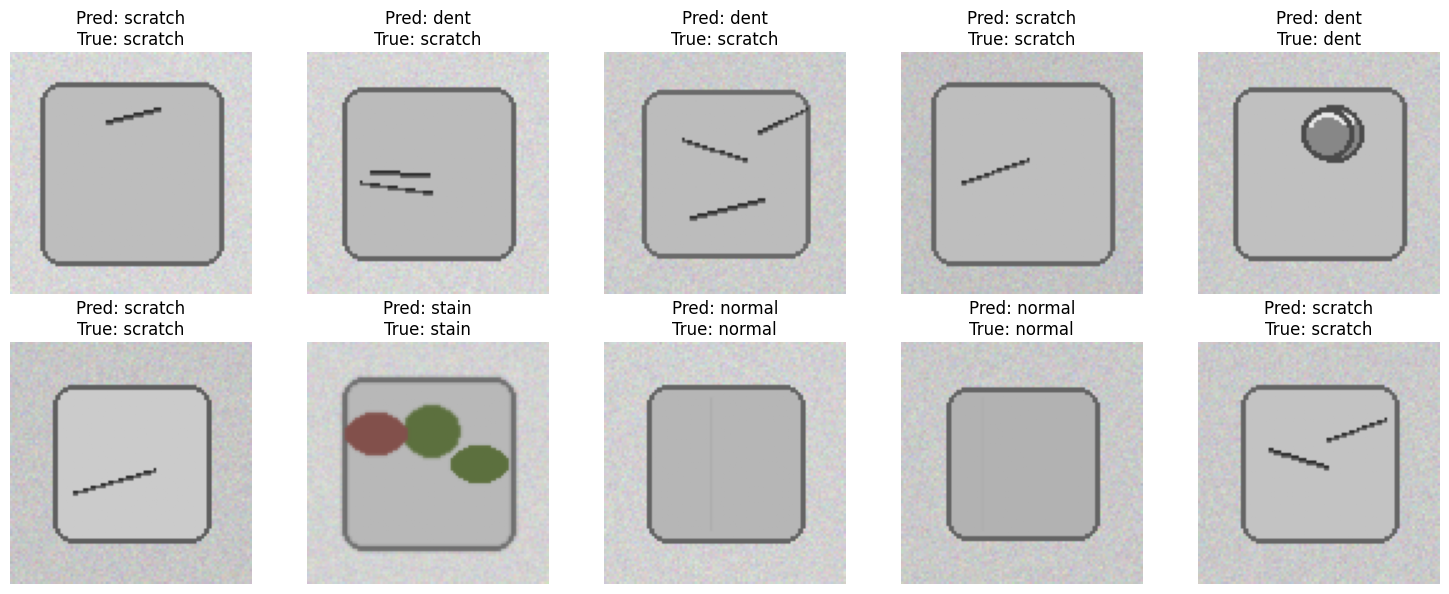

In [47]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):

    ax.imshow(X_test[i])

    predicted_label = classes[y_pred_classes[i]]

    true_label = classes[y_test[i]]

    ax.set_title(
        f"Pred: {predicted_label}\nTrue: {true_label}"
    )

    ax.axis('off')

plt.tight_layout()

plt.savefig(
    "sample_predictions/prediction_outputs.png"
)

plt.show()

## Sample Prediction Analysis

Sample test image predictions demonstrate the CNN model’s ability to classify manufacturing defects into the correct categories.

# Task 6: CNN Concept Explanation

## What is Convolution?

Convolution is a mathematical operation used in CNNs to extract important visual features from images such as edges, textures, dents, scratches, and stains.

CNN filters slide across the image and detect meaningful patterns automatically.

---

## Why is Pooling Used?

Pooling is used to reduce the size of feature maps while keeping the most important information.

Benefits of pooling:
- Reduces computational complexity
- Speeds up training
- Helps prevent overfitting
- Makes the model more efficient

MaxPooling is the most commonly used pooling technique in CNNs.

---

## Why is ReLU Commonly Used in CNNs?

ReLU (Rectified Linear Unit) is commonly used because:
- It introduces non-linearity
- Helps CNNs learn complex image patterns
- Improves training speed
- Reduces the vanishing gradient problem

ReLU formula:

f(x) = max(0, x)

---

## Why are CNNs Better than Regular Feed-Forward Networks for Image Data?

CNNs are better for image data because they:
- Automatically extract spatial features
- Preserve image structure
- Require fewer parameters than fully connected networks
- Learn visual patterns efficiently

Feed-forward neural networks flatten images and lose spatial relationships, while CNNs maintain important visual information through convolution operations.

# Task 7: Business Use Case Mapping

## Manufacturing Industry Use Case

This CNN-based computer vision solution can be highly useful in the manufacturing industry for automated quality inspection.

Manufacturing companies produce large numbers of products daily, making manual defect inspection time-consuming and error-prone. A CNN model can automatically analyze product images and detect defects such as:
- dents
- scratches
- stains
- surface abnormalities

Benefits of using CNN-based defect detection:
- Faster quality inspection
- Reduced human error
- Improved product consistency
- Lower operational cost
- Real-time monitoring in production lines

The system can be integrated with cameras on assembly lines to automatically classify defective and non-defective products before packaging and shipment.